[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alanturin-g/Computational_Neuroscience_UNITO/blob/main/Perotti_4b_machine_learning_exercises.ipynb)

In [ ]:
# Yes, again..
# File -> Save a copy in Drive
from google.colab import auth; auth.authenticate_user()
from google.colab import drive; drive.mount('/content/drive')

# Machine Learning: The Right Way vs The Wrong Way

---

## Introduction

Machine learning can seem deceptively simple: load data, train a model, get predictions. But doing it **wrong** can lead to:
- **Overfitting**: Your model memorizes training data but fails on new data
- **Data leakage**: Test information sneaks into training
- **Misleading results**: 99% accuracy that means nothing
- **Wasted time**: Models that don't generalize to real problems

Today we'll learn machine learning **the right way** by first seeing what goes wrong when you skip crucial steps.

**Dataset**: Titanic (891 passengers, 7 features, 2 classes: survived/died)

---
## ❌ The WRONG Way: Naive ML

**1. Let's just train a model!** - The naive approach

In [1]:
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# Load data
titanic = sns.load_dataset('titanic')

# Simple preprocessing
titanic = titanic[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']].dropna()
X = titanic.drop('survived', axis=1)
X = X.copy()
X['sex'] = (X['sex'] == 'male').astype(int)  # Encode: male=1, female=0
y = titanic['survived'].values

# Train model on ALL data
model = RandomForestClassifier()
model.fit(X, y)

# Check accuracy on the SAME data
accuracy = model.score(X, y)
print(f"Accuracy: {accuracy:.3f}")
print(f"Wow! {accuracy*100:.1f}% accuracy! We're machine learning experts!")

Accuracy: 0.986
Wow! 98.6% accuracy! We're machine learning experts!


**2. What's wrong with this?** - Understanding the danger

The code above looks simple and gives impressive results, but it's **fundamentally broken**!

### Critical Problems:

**1. No train/test split** 🚨
- We trained on ALL the data and tested on the SAME data
- This is like giving students the exam questions before the test
- The model memorized the answers, not learned patterns
- **Real-world performance**: Unknown and probably terrible

**2. No data normalization** 🚨
- Features have wildly different scales (e.g., 0-5 vs 0-1000)
- Some algorithms (KNN, SVM, Neural Networks) are very sensitive to this
- Large features dominate, small features get ignored

**3. No hyperparameter tuning** 🚨
- We used default parameters (might be terrible for our data)
- Different datasets need different model configurations

**4. No model comparison** 🚨
- Random Forest might not be the best for this data
- We never tried alternatives

**5. No understanding of errors** 🚨
- What did the model get wrong?
- Which classes are confused?
- Is performance balanced across classes?

### The Golden Rule:
**Never test on your training data!** It's the #1 mistake in machine learning.

Let's do it right...

---
## ✅ The RIGHT Way: Proper ML Pipeline

**3. Import libraries** - Everything we need

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

**4. Load and explore the data** - Know what you're working with

In [3]:
# Load Titanic dataset
titanic = sns.load_dataset('titanic')

# Select features and handle missing values
titanic = titanic[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']].dropna()

# Prepare features
X = titanic.drop('survived', axis=1).copy()
X['sex'] = (X['sex'] == 'male').astype(int)  # Encode: male=1, female=0
y = titanic['survived'].values

feature_names = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']
target_names = ['died', 'survived']

print("Titanic Dataset Information:")
print(f"  Samples: {X.shape[0]}")
print(f"  Features: {X.shape[1]}")
print(f"  Classes: {len(np.unique(y))} - {target_names}")
print(f"\nFeature names:")
for i, name in enumerate(feature_names, 1):
    print(f"  {i}. {name}")

# Check class distribution
print(f"\nClass distribution:")
for i, name in enumerate(target_names):
    count = np.sum(y == i)
    print(f"  {name}: {count} samples ({count/len(y)*100:.1f}%)")

Titanic Dataset Information:
  Samples: 714
  Features: 6
  Classes: 2 - ['died', 'survived']

Feature names:
  1. pclass
  2. sex
  3. age
  4. sibsp
  5. parch
  6. fare

Class distribution:
  died: 424 samples (59.4%)
  survived: 290 samples (40.6%)


### 💡 Dealing with Unbalanced Datasets

Our Titanic dataset has **~38% died, ~62% survived** - moderately unbalanced.

**When is a dataset unbalanced?**
- Moderate: 60/40 or 70/30 split
- Severe: 90/10, 95/5, or worse (fraud detection, rare diseases)

**Problems with unbalanced data:**
- Model can get 90% accuracy by always predicting majority class!
- Minority class (often the important one) gets ignored

**Solutions:**

1. **Use stratified splits** (we do this!)
   - `train_test_split(..., stratify=y)` preserves class proportions

2. **Use better metrics**
   - Don't rely only on accuracy
   - Use: F1-score, precision, recall, ROC-AUC
   - Check confusion matrix for each class

3. **Resampling techniques:**
   - **Oversample minority class**: Duplicate minority samples
   - **Undersample majority class**: Remove majority samples
   - **SMOTE**: Create synthetic minority samples

4. **Class weights:**
   - `RandomForestClassifier(class_weight='balanced')`
   - Penalizes mistakes on minority class more

5. **Collect more data** (if possible)
   - Especially for the minority class

**For Titanic:** Moderate imbalance (62/38) is manageable with:
- ✅ Stratified splits
- ✅ Good evaluation metrics (F1, ROC-AUC)
- ✅ Checking confusion matrix for both classes

**5. Understand feature scales** - Why normalization matters

In [4]:
# Look at feature scales
print("Feature scales (before normalization):")
print(f"\n{'Feature':<15s} {'Min':>10s} {'Max':>10s} {'Range':>12s}")
print("-" * 50)
for i, name in enumerate(feature_names):
    min_val = X.iloc[:, i].min()
    max_val = X.iloc[:, i].max()
    range_val = max_val - min_val
    print(f"{name:<15s} {min_val:>10.2f} {max_val:>10.2f} {range_val:>12.2f}")

print("\n💡 Notice: Features have VERY different scales!")
print("   fare: 0-512 range")
print("   pclass: 1-3 range")
print("   This WILL cause problems for distance-based algorithms!")

Feature scales (before normalization):

Feature                Min        Max        Range
--------------------------------------------------
pclass                1.00       3.00         2.00
sex                   0.00       1.00         1.00
age                   0.42      80.00        79.58
sibsp                 0.00       5.00         5.00
parch                 0.00       6.00         6.00
fare                  0.00     512.33       512.33

💡 Notice: Features have VERY different scales!
   fare: 0-512 range
   pclass: 1-3 range
   This WILL cause problems for distance-based algorithms!


**6. Train/Test Split** - The foundation of honest evaluation

In [5]:
# Split data: 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y  # stratify keeps class proportions
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\n💡 Key principle: Train on training set, evaluate on test set")
print("   The model never sees test data during training!")

Training set: 499 samples
Test set: 215 samples

💡 Key principle: Train on training set, evaluate on test set
   The model never sees test data during training!


**7. Data Normalization** - Putting features on equal footing

In [6]:
# Standardize features: mean=0, std=1
print("Before normalization:")
print(f"Training set mean (first 3 features): {X_train.mean(axis=0)[:3]}")
print(f"Training set std (first 3 features):  {X_train.std(axis=0)[:3]}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on training data only!
X_test_scaled = scaler.transform(X_test)        # Apply same transformation to test

print("\nAfter normalization:")
print(f"Training set mean: {X_train_scaled.mean(axis=0)[:3]}...")  # Should be ~0
print(f"Training set std:  {X_train_scaled.std(axis=0)[:3]}...")   # Should be ~1

print(f"\n💡 Critical: We fit the scaler on training data ONLY!")
print("   Then apply the same transformation to test data")
print("   Otherwise we leak information from test to training")

Before normalization:
Training set mean (first 3 features): pclass     2.230461
sex        0.641283
age       29.677014
dtype: float64
Training set std (first 3 features):  pclass     0.841324
sex        0.480105
age       14.579322
dtype: float64

After normalization:
Training set mean: [-1.10354834e-16  8.54360003e-17 -9.43355837e-17]...
Training set std:  [1. 1. 1.]...

💡 Critical: We fit the scaler on training data ONLY!
   Then apply the same transformation to test data
   Otherwise we leak information from test to training


---
## Model Selection: Four Classic Algorithms

### K-Nearest Neighbors (KNN)

**How it works:** Classify based on the majority vote of K nearest neighbors

**Intuition:** "You are the average of your K closest friends"

**Pros:** Simple, no training, works well for simple patterns

**Cons:** Slow for large datasets, sensitive to feature scales

![KNN](https://miro.medium.com/v2/1*NMTvXlbr_h3L2s_L3qhvQA.png)

### Support Vector Machine (SVM)

**How it works:** Find the optimal boundary that maximally separates classes

**Intuition:** "Draw the widest possible line between classes"

**Pros:** Effective in high dimensions, memory efficient

**Cons:** Requires scaling, can be slow, hard to interpret

![SVM](https://miro.medium.com/v2/1*jO3m9mIJ1YCE3bR1W-lKcA.png)

### Decision Tree / Random Forest

**How it works:** Learn if/then rules; Random Forest combines many trees

**Intuition:** "20 questions game" repeated many times

**Pros:** Easy to interpret, handles mixed data types, no scaling needed

**Cons:** Can overfit, unstable

![Decision Tree](https://towardsdatascience.com/wp-content/uploads/2022/05/1oUzKoJLSobKLwxGwXXxtYg.png)

### Multi-Layer Perceptron (MLP)

**How it works:** Neural network with hidden layers that learns hierarchical representations

**Intuition:** "Network of simple units learning complex patterns"

**Pros:** Learns complex non-linear relationships, scales well

**Cons:** Needs lots of data, many hyperparameters, black box

![MLP](https://vitalflux.com/wp-content/uploads/2023/02/Sklearn-Neural-Network-MLPRegressor-Regression-Model-.png)

### How Do These Models Learn? Gradient Descent

**The Universal Learning Algorithm**

Most machine learning models (SVM, MLP, Logistic Regression) learn using **gradient descent**:

**The Idea:** Imagine you're lost in foggy mountains and want to reach the valley (minimum error):
1. Look around and find which direction goes downhill (compute gradient)
2. Take a step in that direction (update parameters)
3. Repeat until you reach the bottom (convergence)

**Key Concepts:**
- **Loss function**: How wrong is the model? (height on the mountain)
- **Gradient**: Which direction reduces error the most? (steepest descent)
- **Learning rate**: How big are the steps? (too big = overshoot, too small = slow)

**The Challenge:** Local minima vs global minimum

![Gradient Descent](https://davidmatablog.wordpress.com/wp-content/uploads/2017/08/localminima.png)

💡 **Why this matters:**
- Random Forest doesn't use gradient descent (decision trees)
- KNN doesn't "learn" at all (just memorizes data)
- SVM and MLP heavily rely on gradient descent
- This is why **random initialization** and **learning rate** matter!

**8. Train multiple models** - Compare different algorithms

In [7]:
# Initialize models
models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=30, max_depth=5, random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(10, 5), max_iter=500, random_state=42)
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    # KNN, SVM, MLP need scaled data; Random Forest doesn't
    if name == 'Random Forest':
        model.fit(X_train, y_train)
        train_acc = model.score(X_train, y_train)
        test_acc = model.score(X_test, y_test)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        model.fit(X_train_scaled, y_train)
        train_acc = model.score(X_train_scaled, y_train)
        test_acc = model.score(X_test_scaled, y_test)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    results[name] = {
        'model': model,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'predictions': y_pred,
        'probabilities': y_proba
    }
    
    print(f"  Training accuracy: {train_acc:.3f}")
    print(f"  Test accuracy:     {test_acc:.3f}")
    print()

print("💡 Notice the gap between training and test accuracy?")
print("   Large gap = overfitting (memorizing training data)")
print("   Small gap = good generalization")

Training KNN...
  Training accuracy: 0.868
  Test accuracy:     0.777

Training SVM...
  Training accuracy: 0.848
  Test accuracy:     0.819

Training Random Forest...
  Training accuracy: 0.884
  Test accuracy:     0.795

Training MLP...
  Training accuracy: 0.866
  Test accuracy:     0.795

💡 Notice the gap between training and test accuracy?
   Large gap = overfitting (memorizing training data)
   Small gap = good generalization


**9. Visualize model comparison** - See performance at a glance

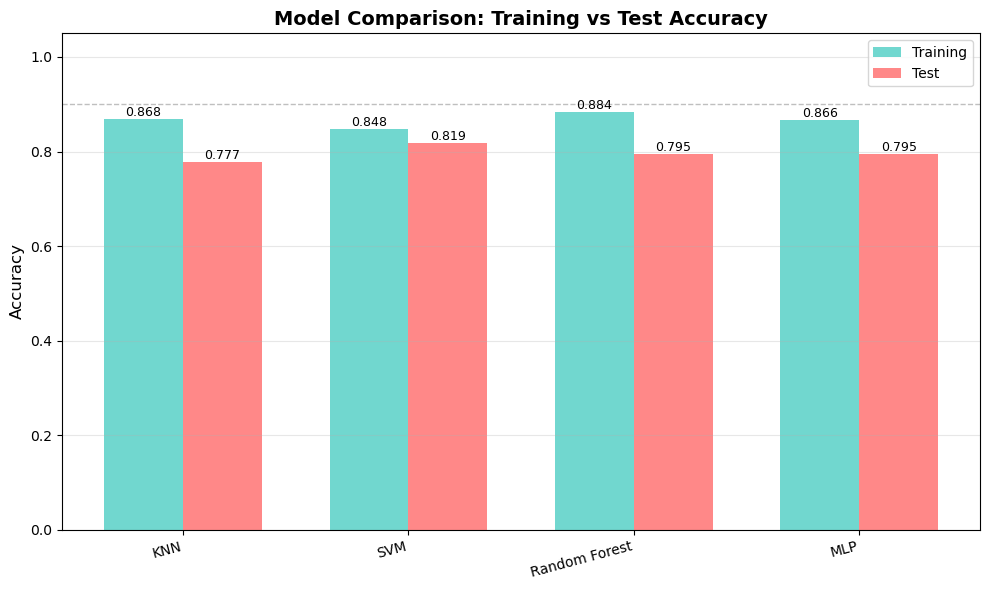


💡 What to look for:
   - Test accuracy tells us real-world performance
   - Large gap = overfitting (model too complex for data)
   - Similar train/test = good generalization


In [8]:
# Create comparison plot
model_names = list(results.keys())
train_accs = [results[name]['train_acc'] for name in model_names]
test_accs = [results[name]['test_acc'] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, train_accs, width, label='Training', color='#4ECDC4', alpha=0.8)
bars2 = ax.bar(x + width/2, test_accs, width, label='Test', color='#FF6B6B', alpha=0.8)

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Comparison: Training vs Test Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend()
ax.set_ylim([0, 1.05])
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.9, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n💡 What to look for:")
print("   - Test accuracy tells us real-world performance")
print("   - Large gap = overfitting (model too complex for data)")
print("   - Similar train/test = good generalization")

---
## Understanding Model Performance

### What is a Confusion Matrix?

A **confusion matrix** shows where your model gets confused!

**Structure:**
- **Rows**: True labels (what it actually is)
- **Columns**: Predicted labels (what model thinks it is)
- **Diagonal**: Correct predictions ✅
- **Off-diagonal**: Mistakes ❌

**Reading it:**
- Entry at (i, j) = "samples that are actually class i but predicted as class j"
- High diagonal values = good!
- High off-diagonal values = model confuses those classes

**Why it's useful:**
- Reveals which classes are confused
- More informative than accuracy alone
- Example: 90% accuracy might hide that the model always fails on one class!

💡 **Accuracy can be misleading, confusion matrix shows the full picture**

**10. Confusion matrices** - See where models make mistakes

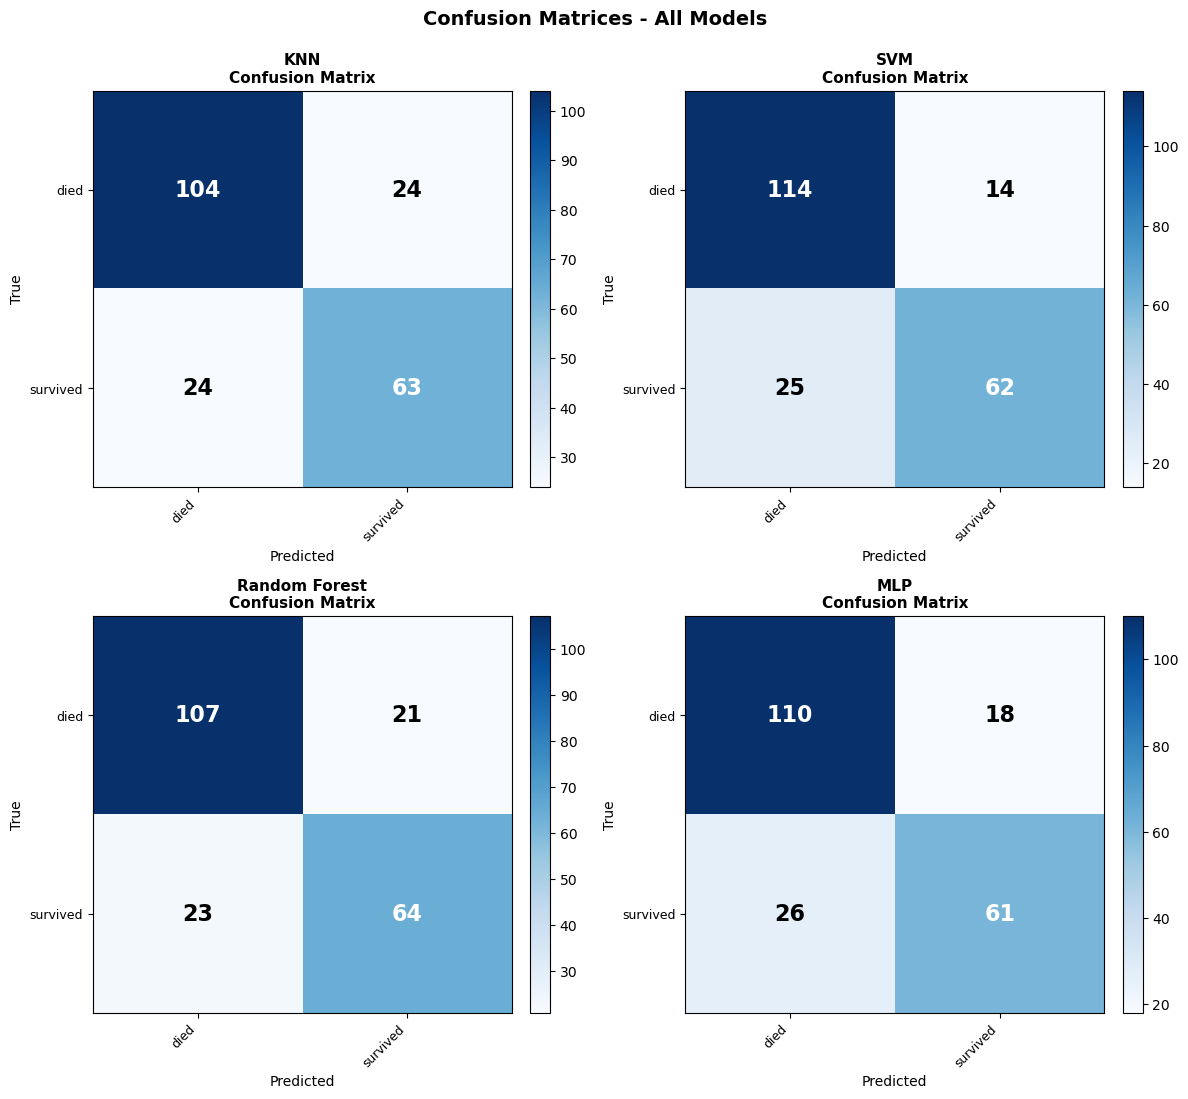


💡 How to read:
   - Bright diagonal = good predictions
   - Bright off-diagonal = common mistakes
   - False positives vs false negatives have different costs!


In [9]:
# Create confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
axes = axes.ravel()

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['predictions'])
    
    # Plot confusion matrix
    im = axes[idx].imshow(cm, cmap='Blues', aspect='auto', interpolation='nearest')
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontweight='bold', fontsize=11)
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('True', fontsize=10)
    axes[idx].set_xticks([0, 1])
    axes[idx].set_yticks([0, 1])
    axes[idx].set_xticklabels(target_names, rotation=45, ha='right', fontsize=9)
    axes[idx].set_yticklabels(target_names, fontsize=9)
    axes[idx].grid(False)
    
    # Add cell values
    for i in range(2):
        for j in range(2):
            text_color = 'white' if cm[i, j] > cm.max()/2 else 'black'
            axes[idx].text(j, i, cm[i, j], ha='center', va='center', 
                         fontsize=16, color=text_color, fontweight='bold')
    
    plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)

plt.suptitle('Confusion Matrices - All Models', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n💡 How to read:")
print("   - Bright diagonal = good predictions")
print("   - Bright off-diagonal = common mistakes")
print("   - False positives vs false negatives have different costs!")

### What is ROC-AUC?

**ROC (Receiver Operating Characteristic)** curve shows classifier performance across all thresholds.

**The Plot:**
- **X-axis**: False Positive Rate (FPR) = mistakes (saying yes when it's no)
- **Y-axis**: True Positive Rate (TPR) = correct positives (saying yes when it's yes)
- **Diagonal line**: Random guessing (coin flip)

**AUC (Area Under Curve)** - Single number summarizing performance:
- **AUC = 1.0**: Perfect! (curve hugs top-left corner)
- **AUC = 0.9-1.0**: Excellent
- **AUC = 0.8-0.9**: Good
- **AUC = 0.7-0.8**: Acceptable
- **AUC = 0.5**: Random guessing (on diagonal)
- **AUC < 0.5**: Something is very wrong!

**Why it's useful:**
- Works great with imbalanced classes
- Shows trade-off between catching positives and avoiding false alarms
- Single metric for easy model comparison

💡 **If your curve is close to the top-left corner, your model is doing great!**

**11. ROC-AUC Curves** - Performance across all thresholds

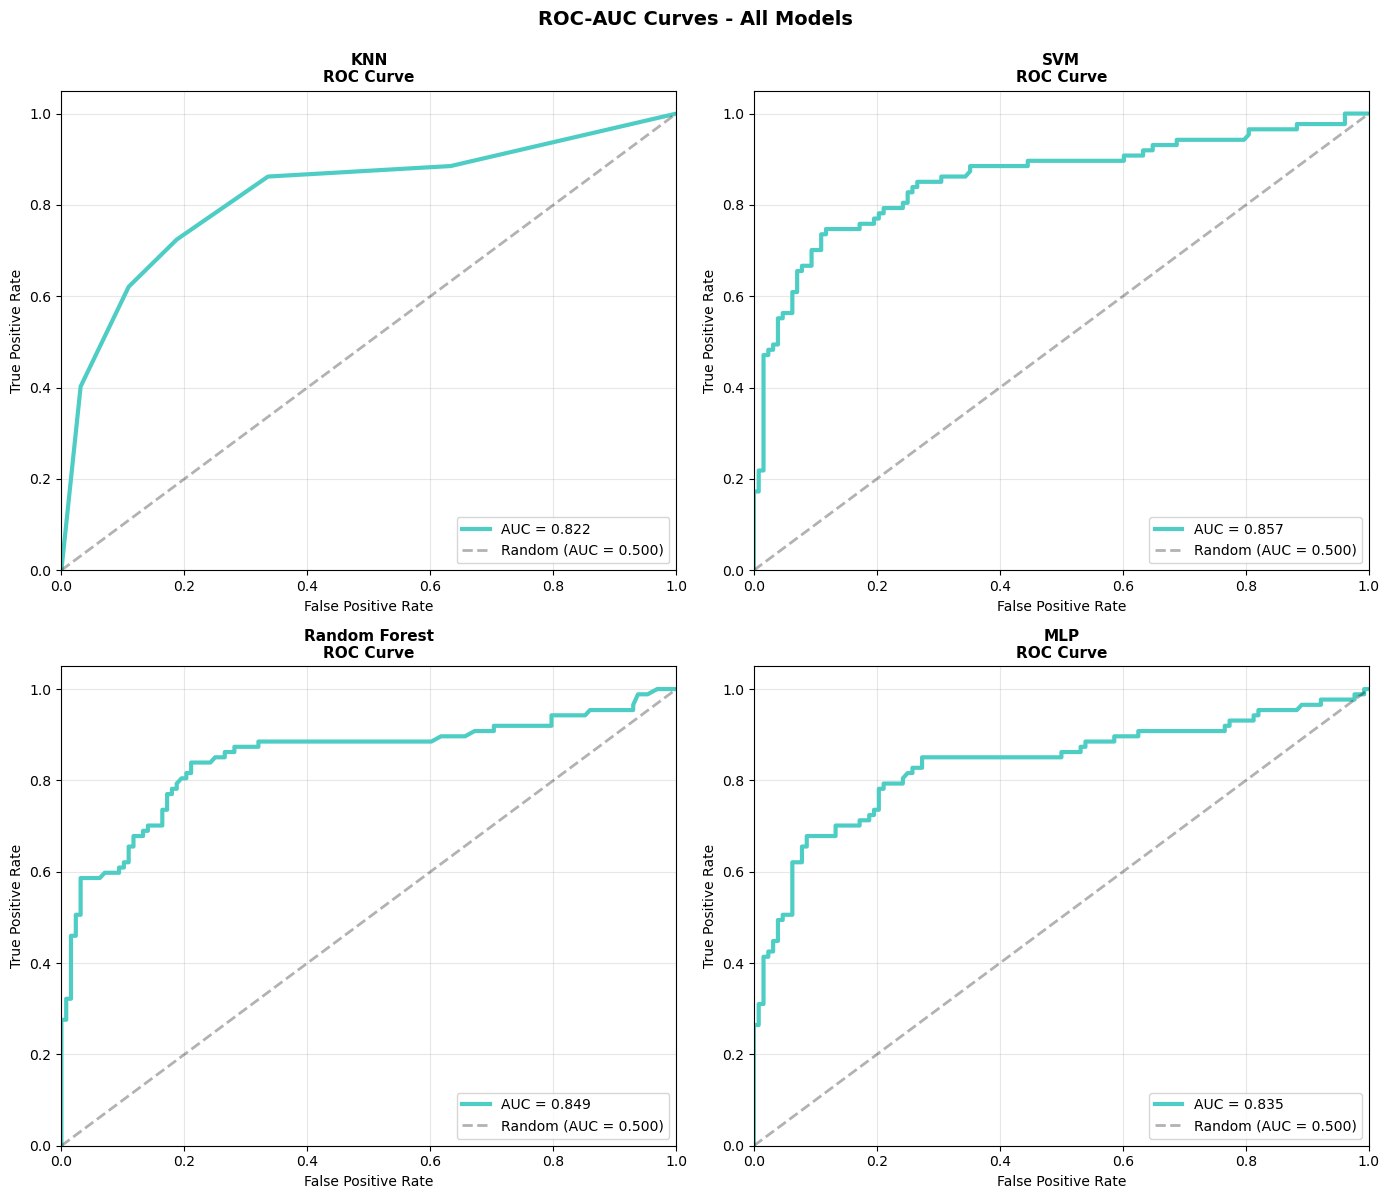


💡 How to interpret:
   - Curve hugging top-left = excellent
   - On the diagonal = random guessing
   - Higher AUC = better overall performance
   - For survival: balance between false alarms and missed cases


In [10]:
# Create ROC curves for all models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (name, result) in enumerate(results.items()):
    y_proba = result['probabilities']
    
    # Compute ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    # Plot
    axes[idx].plot(fpr, tpr, color='#4ECDC4', lw=3, label=f'AUC = {roc_auc:.3f}')
    axes[idx].plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.3, label='Random (AUC = 0.500)')
    axes[idx].set_xlim([0.0, 1.0])
    axes[idx].set_ylim([0.0, 1.05])
    axes[idx].set_xlabel('False Positive Rate', fontsize=10)
    axes[idx].set_ylabel('True Positive Rate', fontsize=10)
    axes[idx].set_title(f'{name}\nROC Curve', fontweight='bold', fontsize=11)
    axes[idx].legend(loc="lower right", fontsize=10)
    axes[idx].grid(alpha=0.3)

plt.suptitle('ROC-AUC Curves - All Models', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n💡 How to interpret:")
print("   - Curve hugging top-left = excellent")
print("   - On the diagonal = random guessing")
print("   - Higher AUC = better overall performance")
print("   - For survival: balance between false alarms and missed cases")

**12. Cross-Validation: Why Multiple Splits Matter** - Reliable evaluation

**13. Detailed classification report** - Precision, Recall, F1-Score

In [11]:
# Show detailed metrics for best model
best_model_name = max(results.keys(), key=lambda x: results[x]['test_acc'])
best_predictions = results[best_model_name]['predictions']

print(f"Detailed Report for Best Model: {best_model_name}")
print("=" * 60)
print(classification_report(y_test, best_predictions, target_names=target_names))

print("\n💡 Understanding the metrics:")
print("   Precision: Of all predicted as malignant, how many actually are?")
print("   Recall: Of all actual malignant cases, how many did we catch?")
print("   F1-Score: Harmonic mean of precision and recall")
print("\n   For survival: Both precision and recall matter across all classes is ideal")

Detailed Report for Best Model: SVM
              precision    recall  f1-score   support

        died       0.82      0.89      0.85       128
    survived       0.82      0.71      0.76        87

    accuracy                           0.82       215
   macro avg       0.82      0.80      0.81       215
weighted avg       0.82      0.82      0.82       215


💡 Understanding the metrics:
   Precision: Of all predicted as malignant, how many actually are?
   Recall: Of all actual malignant cases, how many did we catch?
   F1-Score: Harmonic mean of precision and recall

   For survival: Both precision and recall matter across all classes is ideal


**15. Overfitting vs Underfitting** - Finding the sweet spot

Exploring Model Complexity (Random Forest max_depth):

  Depth=1       Train: 0.788  Test: 0.767  Gap: 0.020
  Depth=2       Train: 0.816  Test: 0.791  Gap: 0.025
  Depth=3       Train: 0.832  Test: 0.781  Gap: 0.050
  Depth=5       Train: 0.884  Test: 0.795  Gap: 0.088
  Depth=10      Train: 0.958  Test: 0.809  Gap: 0.149
  Depth=20      Train: 0.988  Test: 0.805  Gap: 0.183
  Depth=None    Train: 0.988  Test: 0.809  Gap: 0.179


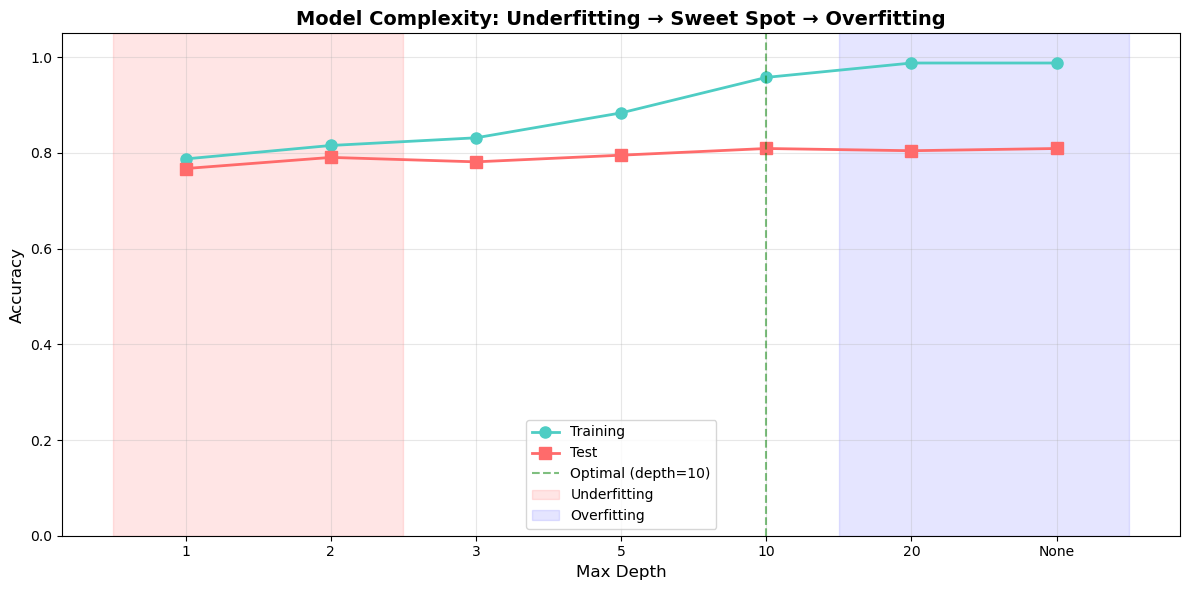


💡 Understanding the Bias-Variance Trade-off:

   🔴 Underfitting (depth = 1-2): Too Simple
      - Both train and test accuracy are LOW
      - Model can't capture data patterns
      - Solution: Increase model complexity

   🟢 Sweet Spot (depth = 10): Just Right
      - Best test accuracy: 0.809
      - Small train-test gap
      - Good generalization!

   🔵 Overfitting (depth = 20/None): Too Complex
      - High training accuracy (→ 1.0)
      - Lower test accuracy
      - Large gap = memorizing training data
      - Solution: Reduce complexity, regularization, more data


In [12]:
# Explore model complexity with Random Forest max_depth
depths = [1, 2, 3, 5, 10, 20, None]
train_accs_depth = []
test_accs_depth = []

print("Exploring Model Complexity (Random Forest max_depth):\n")
for depth in depths:
    rf_depth = RandomForestClassifier(n_estimators=30, max_depth=depth, random_state=42)
    rf_depth.fit(X_train, y_train)
    train_acc = rf_depth.score(X_train, y_train)
    test_acc = rf_depth.score(X_test, y_test)
    train_accs_depth.append(train_acc)
    test_accs_depth.append(test_acc)
    depth_str = str(depth) if depth is not None else 'None'
    print(f"  Depth={depth_str:<6s}  Train: {train_acc:.3f}  Test: {test_acc:.3f}  Gap: {train_acc-test_acc:.3f}")

# Plot
depth_labels = [str(d) if d is not None else 'None' for d in depths]
x_pos = range(len(depths))

plt.figure(figsize=(12, 6))
plt.plot(x_pos, train_accs_depth, 'o-', label='Training', linewidth=2, markersize=8, color='#4ECDC4')
plt.plot(x_pos, test_accs_depth, 's-', label='Test', linewidth=2, markersize=8, color='#FF6B6B')

best_idx = test_accs_depth.index(max(test_accs_depth))
plt.axvline(x=best_idx, color='green', linestyle='--', alpha=0.5, 
           label=f'Optimal (depth={depth_labels[best_idx]})')

# Add regions
plt.axvspan(-0.5, 1.5, alpha=0.1, color='red', label='Underfitting')
plt.axvspan(4.5, 6.5, alpha=0.1, color='blue', label='Overfitting')

plt.xlabel('Max Depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Complexity: Underfitting → Sweet Spot → Overfitting', 
         fontsize=14, fontweight='bold')
plt.xticks(x_pos, depth_labels)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.ylim([0, 1.05])
plt.tight_layout()
plt.show()

print(f"\n💡 Understanding the Bias-Variance Trade-off:")
print(f"\n   🔴 Underfitting (depth = 1-2): Too Simple")
print(f"      - Both train and test accuracy are LOW")
print(f"      - Model can't capture data patterns")
print(f"      - Solution: Increase model complexity")
print(f"\n   🟢 Sweet Spot (depth = {depth_labels[best_idx]}): Just Right")
print(f"      - Best test accuracy: {max(test_accs_depth):.3f}")
print(f"      - Small train-test gap")
print(f"      - Good generalization!")
print(f"\n   🔵 Overfitting (depth = 20/None): Too Complex")
print(f"      - High training accuracy (→ 1.0)")
print(f"      - Lower test accuracy")
print(f"      - Large gap = memorizing training data")
print(f"      - Solution: Reduce complexity, regularization, more data")

**16. Feature Importance** - Which features matter most?

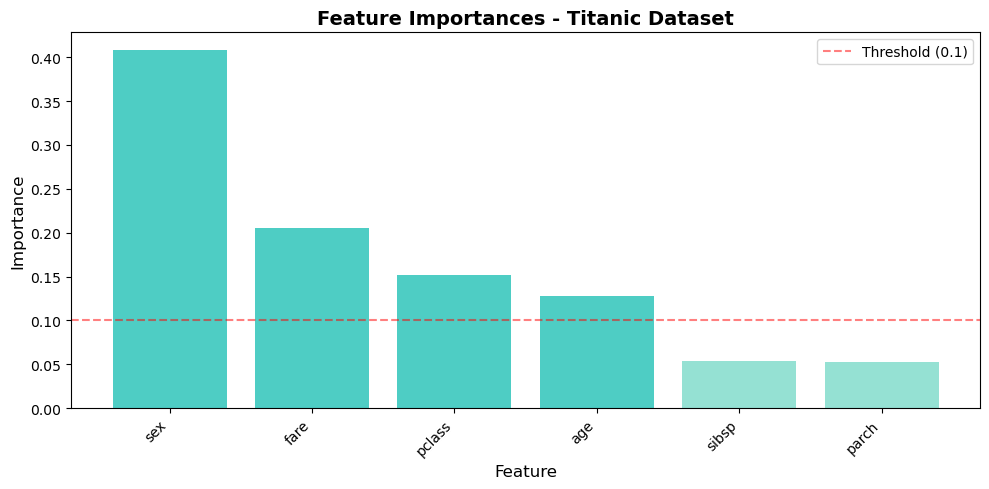


Feature Importances:
  1. sex             0.408
  2. fare            0.206
  3. pclass          0.152
  4. age             0.128
  5. sibsp           0.054
  6. parch           0.052

💡 Key Insights:
   • Sex and pclass are the strongest predictors
   • Fare also contributes significantly
   • Feature importance helps understand which factors matter most

   Benefits of Analyzing Feature Importance:
   ✅ Understand what drives predictions
   ✅ Focus on collecting the most valuable data
   ✅ Simplify models by removing weak features
   ✅ Better interpretability for stakeholders


In [13]:
# Analyze feature importance from our Random Forest model
rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot feature importances
plt.figure(figsize=(10, 5))
colors = ['#4ECDC4' if importances[i] > 0.1 else '#95E1D3' for i in indices]
plt.bar(range(len(importances)), importances[indices], color=colors)
plt.xticks(range(len(importances)), 
          [feature_names[i] for i in indices], 
          rotation=45, ha='right', fontsize=10)
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Importance', fontsize=12)
plt.title('Feature Importances - Titanic Dataset', fontsize=14, fontweight='bold')
plt.axhline(y=0.1, color='r', linestyle='--', alpha=0.5, label='Threshold (0.1)')
plt.legend()
plt.tight_layout()
plt.show()

# Print all features
print("\nFeature Importances:")
print("=" * 50)
for rank, i in enumerate(indices, 1):
    print(f"  {rank}. {feature_names[i]:<15s} {importances[i]:.3f}")

print("\n💡 Key Insights:")
print("   • Sex and pclass are the strongest predictors")
print("   • Fare also contributes significantly")
print("   • Feature importance helps understand which factors matter most")
print("\n   Benefits of Analyzing Feature Importance:")
print("   ✅ Understand what drives predictions")
print("   ✅ Focus on collecting the most valuable data")
print("   ✅ Simplify models by removing weak features")
print("   ✅ Better interpretability for stakeholders")

Cross-Validation Demonstration

📊 PART 1: Comparing Models with Cross-Validation
----------------------------------------------------------------------
Cross-validation splits data into K folds, trains on K-1, tests on 1,
repeats K times with different test folds. More reliable than single split!

Model              CV Mean     CV Std  Single Test
----------------------------------------------------
KNN                  0.802      0.040        0.777
SVM                  0.814      0.048        0.819
Random Forest        0.812      0.045        0.795
MLP                  0.814      0.035        0.795

💡 Interpreting the results:
   • CV Mean ≈ Single Test accuracy → Good sign!
   • Large CV Std → Model is unstable
   • CV gives us confidence intervals, not just a single number


📊 PART 2: Why Cross-Validation is More Reliable
----------------------------------------------------------------------
Running 10 different train/test splits...
Running 5-fold cross-validation...


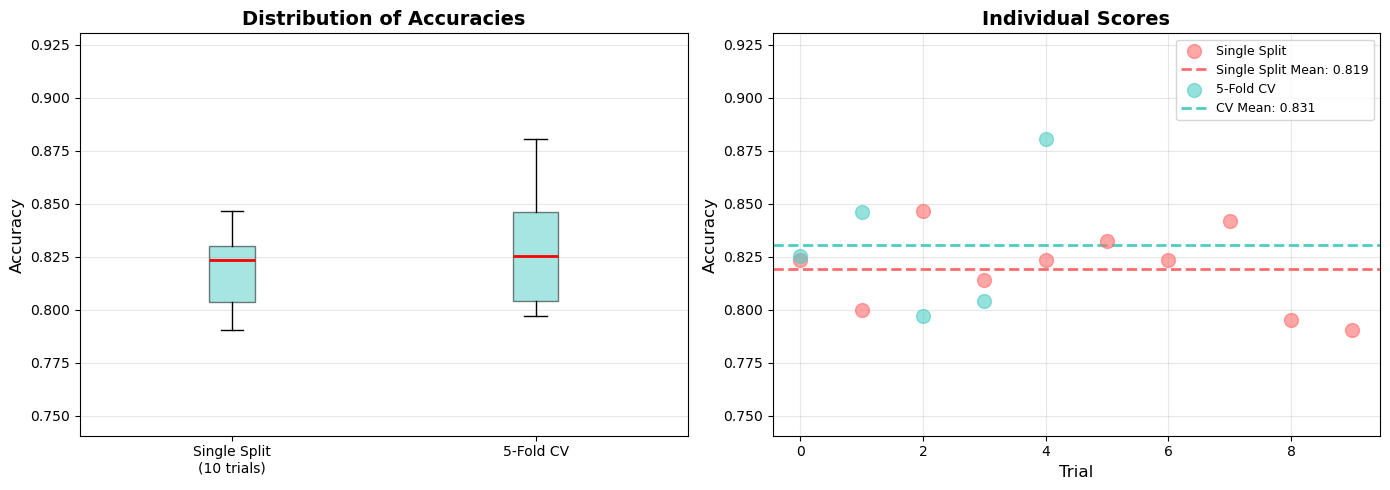


Statistical Comparison:

Single Split (10 different random splits):
  Mean:    0.819
  Std:     0.018
  Range:   0.791 - 0.847

5-Fold Cross-Validation:
  Mean:    0.831
  Std:     0.030
  Range:   0.797 - 0.880

💡 Key Takeaways:

   Single Split Problems:
   • Results vary wildly based on random split
   • You might get lucky or unlucky
   • Variance: 0.018

   Cross-Validation Wins:
   • Every sample used for testing exactly once
   • More stable: variance = 0.030
   • Better estimate of true performance
   • Essential for small datasets!


In [14]:
# Cross-validation: More reliable than single split
print("Cross-Validation Demonstration")
print("=" * 70)

# PART 1: Compare models using CV
print("\n📊 PART 1: Comparing Models with Cross-Validation")
print("-" * 70)
print("Cross-validation splits data into K folds, trains on K-1, tests on 1,")
print("repeats K times with different test folds. More reliable than single split!\n")

print(f"{'Model':<15s} {'CV Mean':>10s} {'CV Std':>10s} {'Single Test':>12s}")
print("-" * 52)

for name, result in results.items():
    model = result['model']
    
    # Use appropriate data (scaled or not)
    if name == 'Random Forest':
        cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    else:
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    test_acc = result['test_acc']
    
    print(f"{name:<15s} {cv_mean:>10.3f} {cv_std:>10.3f} {test_acc:>12.3f}")

print("\n💡 Interpreting the results:")
print("   • CV Mean ≈ Single Test accuracy → Good sign!")
print("   • Large CV Std → Model is unstable")
print("   • CV gives us confidence intervals, not just a single number")

# PART 2: Single split vs CV reliability
print("\n\n📊 PART 2: Why Cross-Validation is More Reliable")
print("-" * 70)

# Method 1: Multiple single splits with different random seeds
single_split_accs_demo = []
print("Running 10 different train/test splits...")
for seed in range(10):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y
    )
    scaler_temp = StandardScaler()
    X_tr_scaled = scaler_temp.fit_transform(X_tr)
    X_te_scaled = scaler_temp.transform(X_te)
    
    svm_temp = SVC(random_state=42)
    svm_temp.fit(X_tr_scaled, y_tr)
    acc = svm_temp.score(X_te_scaled, y_te)
    single_split_accs_demo.append(acc)

# Method 2: Cross-validation
print("Running 5-fold cross-validation...")
from sklearn.pipeline import Pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()), 
    ('svm', SVC(random_state=42))
])
cv_accs_demo = cross_val_score(pipe, X, y, cv=5)

# Visualize comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
bp1 = ax1.boxplot([single_split_accs_demo, cv_accs_demo], 
                   labels=['Single Split\n(10 trials)', '5-Fold CV'],
                   patch_artist=True)
for patch in bp1['boxes']:
    patch.set_facecolor('#4ECDC4')
    patch.set_alpha(0.5)
for median in bp1['medians']:
    median.set_color('red')
    median.set_linewidth(2)

ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Distribution of Accuracies', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([min(min(single_split_accs_demo), min(cv_accs_demo)) - 0.05, 
              max(max(single_split_accs_demo), max(cv_accs_demo)) + 0.05])

# Scatter plot
ax2.scatter(range(len(single_split_accs_demo)), single_split_accs_demo, 
           s=100, alpha=0.6, label='Single Split', color='#FF6B6B', zorder=3)
ax2.axhline(np.mean(single_split_accs_demo), color='#FF6B6B', 
           linestyle='--', linewidth=2, 
           label=f'Single Split Mean: {np.mean(single_split_accs_demo):.3f}')

ax2.scatter(range(len(cv_accs_demo)), cv_accs_demo, 
           s=100, alpha=0.6, label='5-Fold CV', color='#4ECDC4', zorder=3)
ax2.axhline(np.mean(cv_accs_demo), color='#4ECDC4', 
           linestyle='--', linewidth=2, 
           label=f'CV Mean: {np.mean(cv_accs_demo):.3f}')

ax2.set_xlabel('Trial', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Individual Scores', fontsize=14, fontweight='bold')
ax2.legend(fontsize=9, loc='best')
ax2.grid(alpha=0.3)
ax2.set_ylim([min(min(single_split_accs_demo), min(cv_accs_demo)) - 0.05, 
              max(max(single_split_accs_demo), max(cv_accs_demo)) + 0.05])

plt.tight_layout()
plt.show()

# Statistical comparison
print("\nStatistical Comparison:")
print("=" * 70)
print(f"\nSingle Split (10 different random splits):")
print(f"  Mean:    {np.mean(single_split_accs_demo):.3f}")
print(f"  Std:     {np.std(single_split_accs_demo):.3f}")
print(f"  Range:   {np.min(single_split_accs_demo):.3f} - {np.max(single_split_accs_demo):.3f}")

print(f"\n5-Fold Cross-Validation:")
print(f"  Mean:    {np.mean(cv_accs_demo):.3f}")
print(f"  Std:     {np.std(cv_accs_demo):.3f}")
print(f"  Range:   {np.min(cv_accs_demo):.3f} - {np.max(cv_accs_demo):.3f}")

print(f"\n💡 Key Takeaways:")
print(f"\n   Single Split Problems:")
print(f"   • Results vary wildly based on random split")
print(f"   • You might get lucky or unlucky")
print(f"   • Variance: {np.std(single_split_accs_demo):.3f}")
print(f"\n   Cross-Validation Wins:")
print(f"   • Every sample used for testing exactly once")
print(f"   • More stable: variance = {np.std(cv_accs_demo):.3f}")
print(f"   • Better estimate of true performance")
print(f"   • Essential for small datasets!")

---
## Machine Learning: Do's and Don'ts

### ✅ DO:

1. **Always split your data** (train/test or train/val/test)
   - Never test on training data
   - Use stratified splits for imbalanced data

2. **Normalize/standardize features**
   - Especially for KNN, SVM, Neural Networks
   - Fit on training data, apply to test

3. **Try multiple models**
   - No single best algorithm for all problems
   - Start simple, increase complexity if needed

4. **Use cross-validation**
   - More reliable than single train/test split
   - Reveals model stability

5. **Look at confusion matrix**
   - Accuracy alone can be misleading
   - Understand which errors matter

6. **Check for overfitting**
   - Compare training vs test performance
   - Large gap = overfitting

7. **Understand your data**
   - Check class balance
   - Look for outliers
   - Visualize features

8. **Set random seeds**
   - Makes results reproducible
   - Important for debugging

### ❌ DON'T:

1. **Don't train and test on the same data**
   - This is the #1 mistake
   - Leads to over-optimistic results

2. **Don't fit preprocessing on all data**
   - Fit scaler/normalizer on training only
   - Otherwise: data leakage!

3. **Don't trust perfect scores**
   - 100% accuracy usually means a bug
   - Check for data leakage

4. **Don't ignore class imbalance**
   - Use stratified splits
   - Consider appropriate metrics (F1, AUC)

5. **Don't use defaults blindly**
   - Tune hyperparameters
   - Understand what parameters do

6. **Don't forget to scale**
   - KNN, SVM, Neural Nets need it
   - Tree-based methods don't (but doesn't hurt)

7. **Don't only look at accuracy**
   - Use confusion matrix, precision, recall
   - Understand error types

8. **Don't skip exploratory analysis**
   - Understand your data first
   - Look for obvious patterns or problems

### Golden Rules:

🌟 **"Never test on your training data"**

🌟 **"If it looks too good to be true, it probably is"**

🌟 **"Understand your data before modeling"**

🌟 **"Simple models first, complex models only if needed"**

🌟 **"One number (accuracy) is never enough"**

---

# Exercises: Wine Dataset

Now it's your turn! Apply everything you've learned to the **Wine dataset**.

---

## Exercise 1: Complete ML Pipeline

Implement the full machine learning pipeline on the Wine dataset:
1. Load the Wine dataset (`load_wine`)
2. Explore: print dataset info, class distribution, feature scales
3. Split into train/test (70/30) with stratification
4. Normalize the features
5. Train 4 models: KNN, SVM, Random Forest, MLP
6. Compare training vs test accuracy (bar plot)
7. Create confusion matrices for all models (2x2 subplot)
8. Create ROC curves for all models (2x2 subplot)
9. Print classification report for best model
10. Which model performs best? Why?

In [15]:
# YOUR CODE HERE

### Solution:

Wine Dataset:
  Samples: 178
  Features: 13
  Classes: ['class_0' 'class_1' 'class_2']

Class distribution:
  class_0: 59 (33.1%)
  class_1: 71 (39.9%)
  class_2: 48 (27.0%)

Feature scales (first 5):
  alcohol: 11.03 - 14.83
  malic_acid: 0.74 - 5.80
  ash: 1.36 - 3.23
  alcalinity_of_ash: 10.60 - 30.00
  magnesium: 70.00 - 162.00


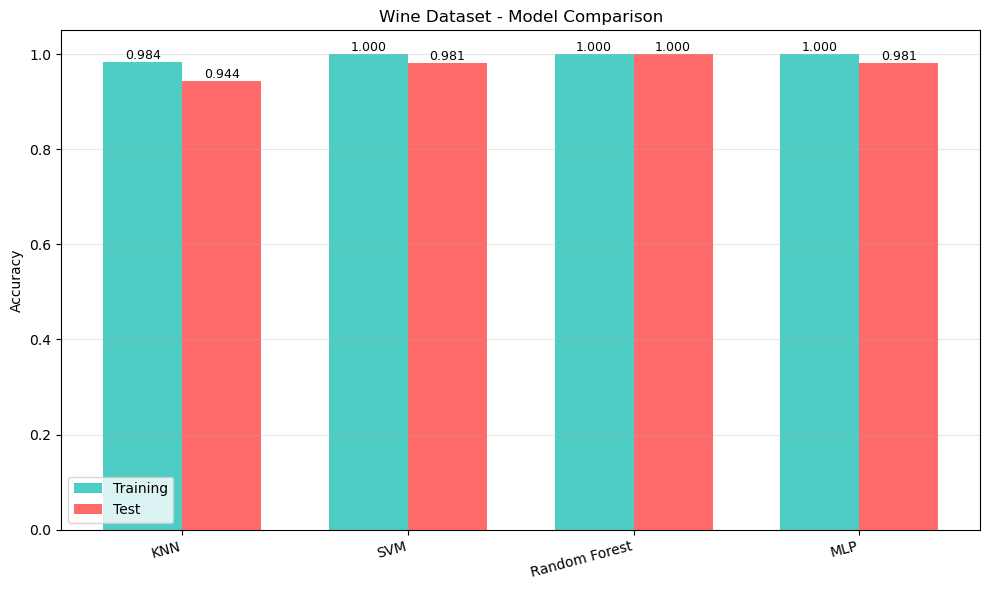

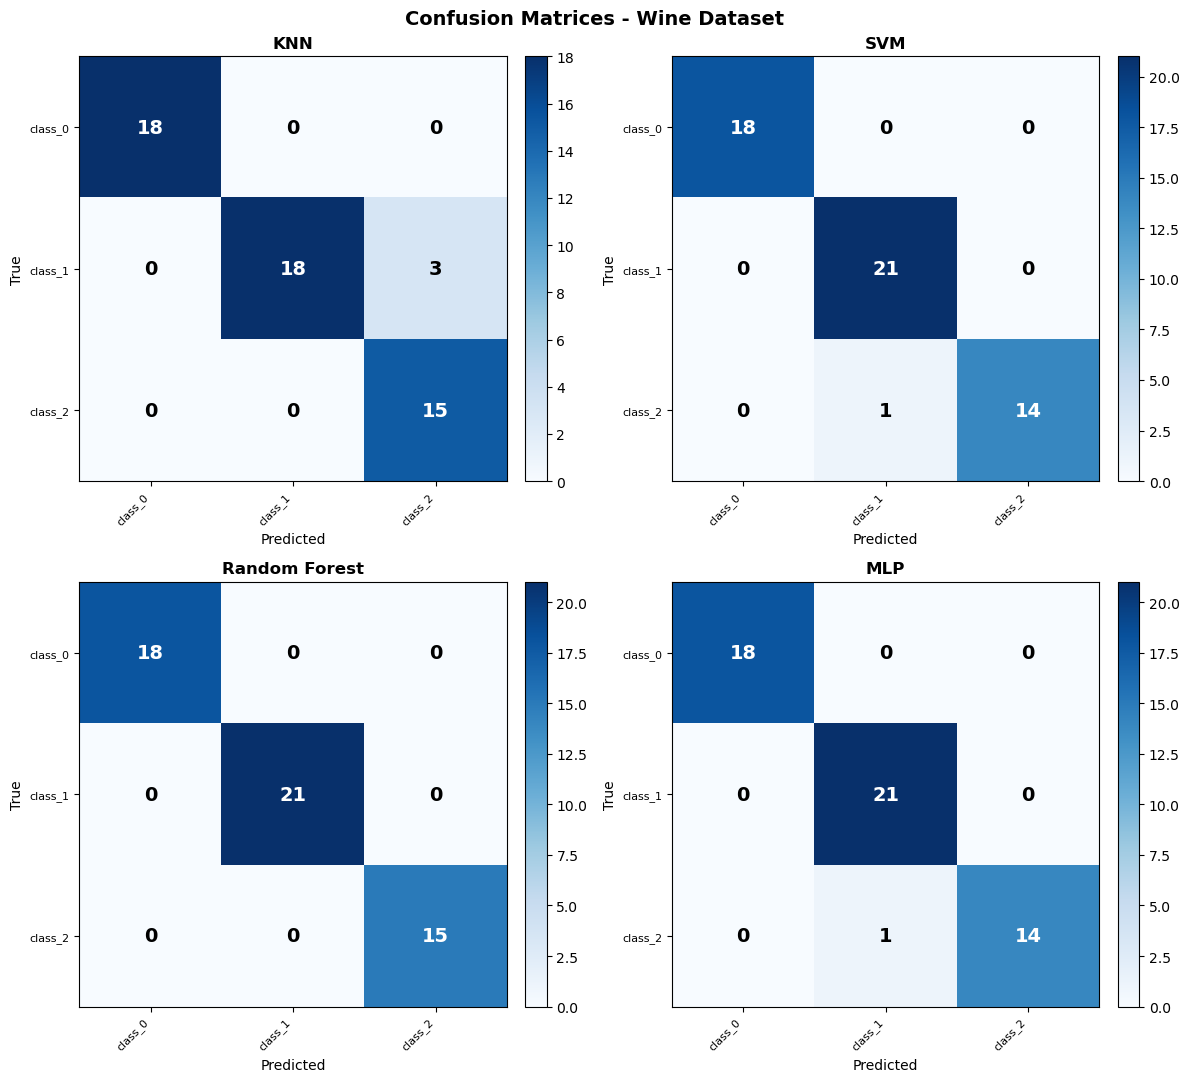

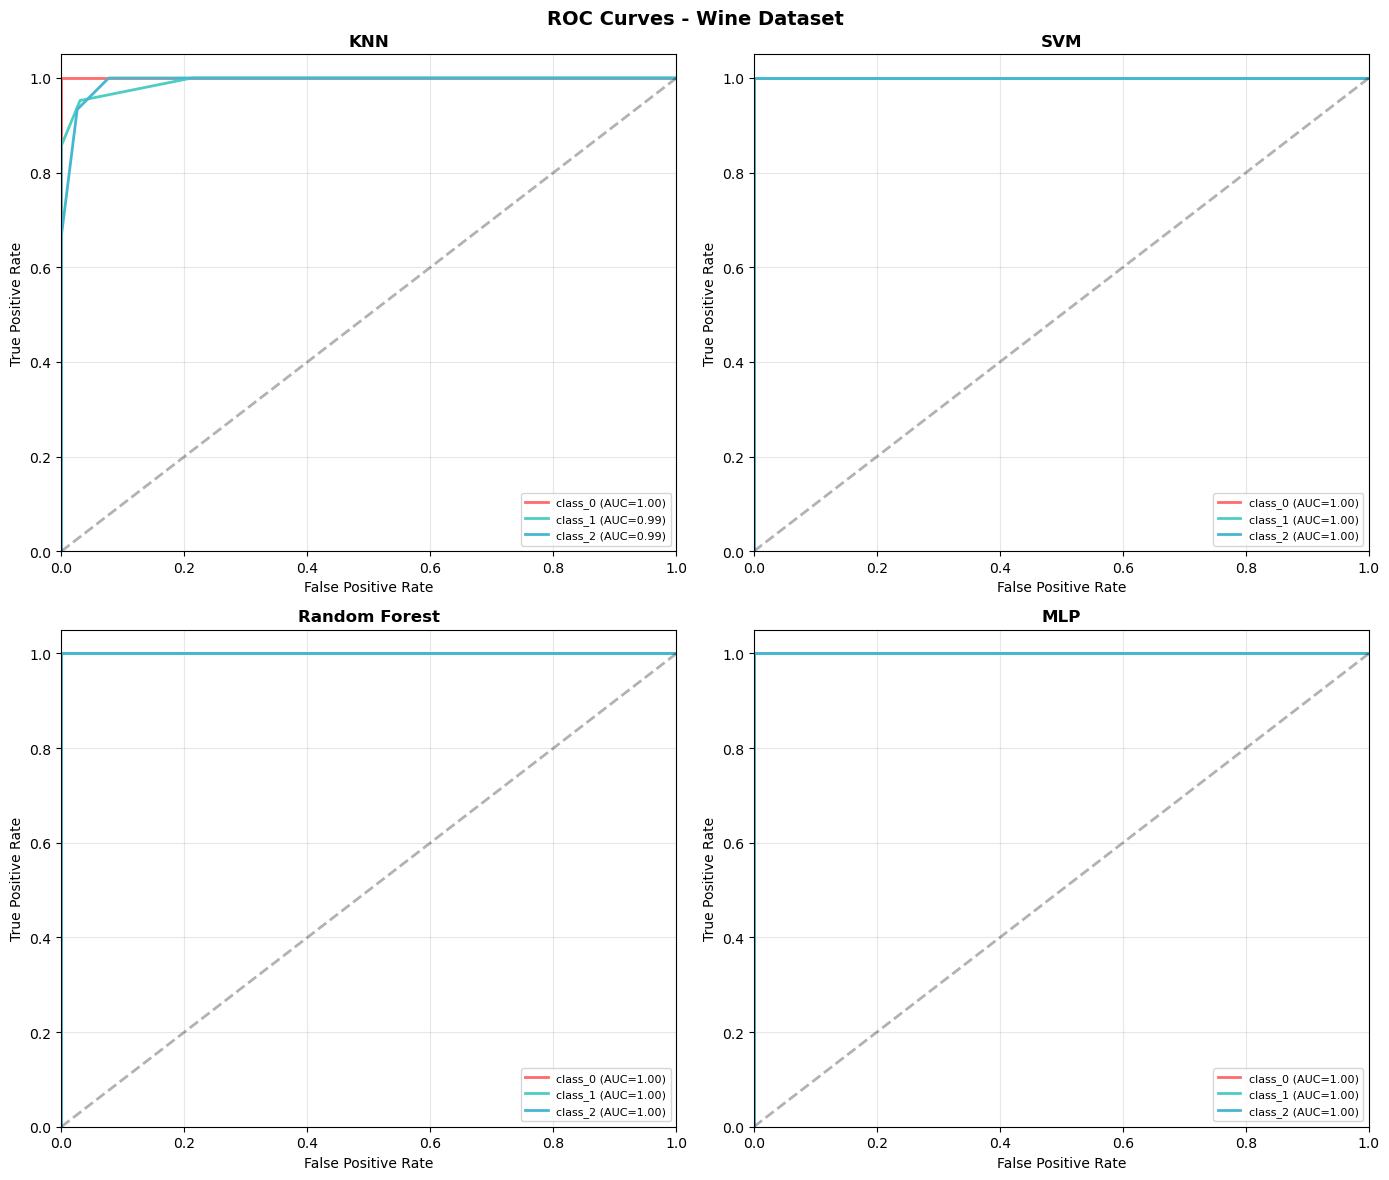


Best Model: Random Forest
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54


💡 Analysis:
   Best model: Random Forest with 1.000 accuracy

   Why this model works well:
   - Robust to feature scales
   - Handles feature interactions well
   - Less prone to overfitting with depth limit


In [16]:
# SOLUTION
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# 1-2. Load and explore
wine = load_wine()
X, y = wine.data, wine.target

print("Wine Dataset:")
print(f"  Samples: {X.shape[0]}")
print(f"  Features: {X.shape[1]}")
print(f"  Classes: {wine.target_names}")
print(f"\nClass distribution:")
for i, name in enumerate(wine.target_names):
    count = np.sum(y == i)
    print(f"  {name}: {count} ({count/len(y)*100:.1f}%)")

print(f"\nFeature scales (first 5):")
for i in range(5):
    print(f"  {wine.feature_names[i]}: {X[:, i].min():.2f} - {X[:, i].max():.2f}")

# 3. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 4. Normalize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train models
models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=30, max_depth=10, random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(20, 10), max_iter=500, random_state=42)
}

results = {}
for name, model in models.items():
    if name == 'Random Forest':
        model.fit(X_train, y_train)
        train_acc = model.score(X_train, y_train)
        test_acc = model.score(X_test, y_test)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        train_acc = model.score(X_train_scaled, y_train)
        test_acc = model.score(X_test_scaled, y_test)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)
    
    results[name] = {
        'train_acc': train_acc,
        'test_acc': test_acc,
        'predictions': y_pred,
        'probabilities': y_proba
    }

# 6. Compare accuracies
model_names = list(results.keys())
train_accs = [results[n]['train_acc'] for n in model_names]
test_accs = [results[n]['test_acc'] for n in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, train_accs, width, label='Training', color='#4ECDC4')
ax.bar(x + width/2, test_accs, width, label='Test', color='#FF6B6B')
ax.set_ylabel('Accuracy')
ax.set_title('Wine Dataset - Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bars in [ax.containers[0], ax.containers[1]]:
    ax.bar_label(bars, fmt='%.3f', fontsize=9)
plt.tight_layout()
plt.show()

# 7. Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
axes = axes.ravel()

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['predictions'])
    im = axes[idx].imshow(cm, cmap='Blues', aspect='auto', interpolation='nearest')
    axes[idx].set_title(f'{name}', fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')
    axes[idx].set_xticks(range(3))
    axes[idx].set_yticks(range(3))
    axes[idx].set_xticklabels(wine.target_names, rotation=45, ha='right', fontsize=8)
    axes[idx].set_yticklabels(wine.target_names, fontsize=8)
    axes[idx].grid(False)
    
    for i in range(3):
        for j in range(3):
            text_color = 'white' if cm[i, j] > cm.max()/2 else 'black'
            axes[idx].text(j, i, cm[i, j], ha='center', va='center', 
                         fontsize=14, color=text_color, fontweight='bold')
    plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)

plt.suptitle('Confusion Matrices - Wine Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 8. ROC curves (One-vs-Rest for multi-class)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (name, result) in enumerate(results.items()):
    for i, color in enumerate(colors):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], result['probabilities'][:, i])
        roc_auc = auc(fpr, tpr)
        axes[idx].plot(fpr, tpr, color=color, lw=2,
                      label=f'{wine.target_names[i]} (AUC={roc_auc:.2f})')
    
    axes[idx].plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.3)
    axes[idx].set_xlim([0.0, 1.0])
    axes[idx].set_ylim([0.0, 1.05])
    axes[idx].set_xlabel('False Positive Rate')
    axes[idx].set_ylabel('True Positive Rate')
    axes[idx].set_title(f'{name}', fontweight='bold')
    axes[idx].legend(loc="lower right", fontsize=8)
    axes[idx].grid(alpha=0.3)

plt.suptitle('ROC Curves - Wine Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 9. Best model report
best_name = max(results.keys(), key=lambda x: results[x]['test_acc'])
print(f"\nBest Model: {best_name}")
print("=" * 60)
print(classification_report(y_test, results[best_name]['predictions'], 
                          target_names=wine.target_names))

# 10. Analysis
print(f"\n💡 Analysis:")
print(f"   Best model: {best_name} with {results[best_name]['test_acc']:.3f} accuracy")
print(f"\n   Why this model works well:")
if best_name == 'SVM':
    print("   - SVM excels with standardized features")
    print("   - Good for high-dimensional data")
    print("   - RBF kernel captures non-linear patterns")
elif best_name == 'Random Forest':
    print("   - Robust to feature scales")
    print("   - Handles feature interactions well")
    print("   - Less prone to overfitting with depth limit")
elif best_name == 'MLP':
    print("   - Learns complex non-linear patterns")
    print("   - Benefits from feature scaling")
elif best_name == 'KNN':
    print("   - Simple but effective for small datasets")
    print("   - Works well when classes are distinct")